In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import statsmodels

print("All working")

All working


In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("../data/raw/ElectroTech Forecasting Data.csv")

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

# Create time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Encode categorical variables
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Category",
        "Season",
        "Product_Specification_1",
        "Product_Specification_2"
    ],
    drop_first=True
)

# Prepare model data
df_model = df_encoded.drop(columns=["Product_ID", "Date"])

X = df_model.drop("Sales_Volume", axis=1)
y = df_model["Sales_Volume"]

# Time-based split
split_index = int(len(df_model) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


## Feature Importance (Random Forest)

This analysis identifies which features have the greatest impact on predicting sales.

Understanding feature importance helps explain why the Random Forest model performs well and provides insight into key business drivers.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance
importance = rf_model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
5,Month,0.613488
0,Price,0.312809
2,Competitor_Activity_Score,0.012821
3,Consumer_Confidence_Index,0.012806
1,Market_Trend_Index,0.012355
6,Day,0.008769
4,Year,0.005829
7,DayOfWeek,0.004730
13,Season_Winter,0.003333
12,Season_Summer,0.003071


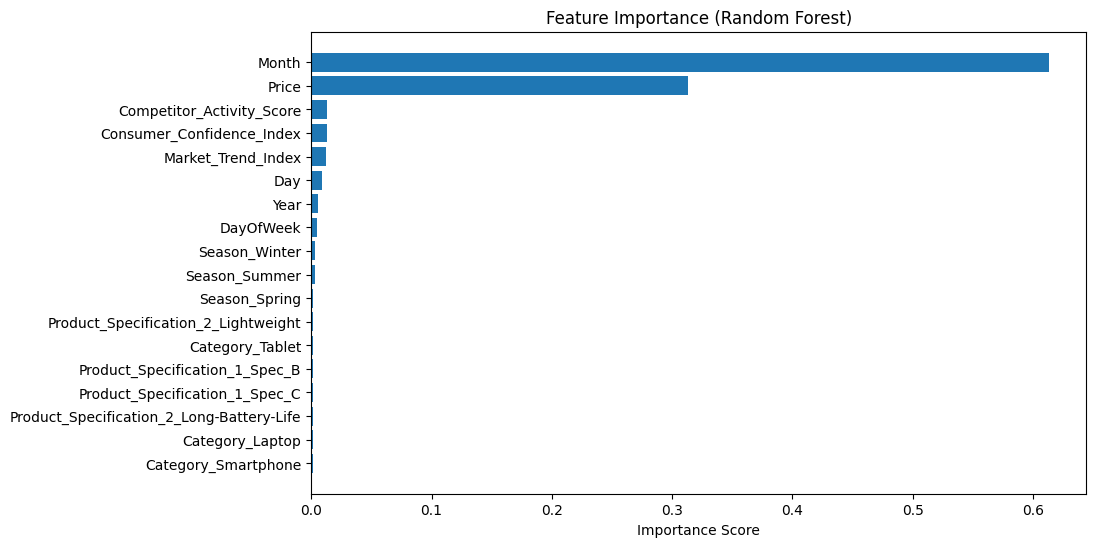

In [7]:
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

In [8]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")
print("Model saved successfully")

Model saved successfully


In [9]:
loaded_model = joblib.load("rf_model.pkl")
print("Model loaded successfully")

Model loaded successfully
